# Evaluating the Models

Notebook 4 developed four models using only the training data, selected one frozen recall-floor threshold for each model, and named gradient boosting as the primary model before the test set was opened.

This notebook now performs the one-time final evaluation on the 2,643 participants in `test_data.csv`. It asks five questions:

1. Did the probability-ranking performance from cross-validation transfer to new participants?
2. Did the frozen thresholds come close to their intended 80% recall target?
3. Are the test-set probabilities still reasonably calibrated?
4. How much uncertainty surrounds the reported results?
5. Under the illustrative cost tradeoff implied by the frozen threshold, does the primary model provide more net benefit than flagging everyone or no one?

All four models are evaluated, but gradient boosting remains the primary result regardless of how the secondary models happen to score. None of the four saved cavity models is retrained, no hyperparameter is changed, and no threshold is adjusted after seeing the test outcomes.

## The Evaluation Plan Was Fixed in Advance

The test set is useful only if it acts like genuinely new data. That requires the important decisions to be made before its outcomes influence the project.

Notebook 4 already fixed the following:

- **Primary model:** gradient boosting
- **Primary model-selection metric:** PR-AUC
- **Operating rule:** use each model's frozen training-derived threshold targeting 80% recall
- **Primary threshold for gradient boosting:** 0.130
- **Secondary comparisons:** logistic regression, random forest, and neural network

The 80% value is an illustrative project operating target, not a clinically validated requirement. Its purpose is to make the tradeoff explicit: the models are asked to catch most cavity cases even though doing so produces many false-positive flags.

Results in this notebook will be reported as they appear. A disappointing test result would be evidence about generalization, not a reason to return to Notebook 4 and choose a more favorable model or cutoff.

## Imports and Setup

This section loads the tools needed for final evaluation, locates the project folders, and preserves the colors used for each model in Notebook 4.

In [1]:
from pathlib import Path
import hashlib
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

from scipy.special import logit
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)


# Find the project folder whether VS Code launches Jupyter from the
# repository root or from inside the notebooks folder.
current_folder = Path.cwd().resolve()
project_candidates = [current_folder, current_folder.parent]

for candidate in project_candidates:
    if (candidate / "data" / "processed" / "test_data.csv").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Could not locate data/processed/test_data.csv. "
        "Open this notebook from inside the project repository."
    )

TRAINING_PATH = PROJECT_ROOT / "data" / "processed" / "training_data.csv"
TEST_PATH = PROJECT_ROOT / "data" / "processed" / "test_data.csv"
MODEL_FOLDER = PROJECT_ROOT / "outputs" / "models"
TABLE_FOLDER = PROJECT_ROOT / "outputs" / "tables"

METADATA_PATH = MODEL_FOLDER / "model_metadata.json"
DEVELOPMENT_RESULTS_PATH = TABLE_FOLDER / "model_development_cv_results.csv"
DEVELOPMENT_CALIBRATION_PATH = TABLE_FOLDER / "model_calibration_results.csv"
DEVELOPMENT_THRESHOLDS_PATH = TABLE_FOLDER / "model_thresholds.csv"

TABLE_FOLDER.mkdir(parents=True, exist_ok=True)
MODEL_FOLDER.mkdir(parents=True, exist_ok=True)


# The same seed is used for the bootstrap so its confidence intervals
# reproduce exactly whenever the notebook is rerun.
RANDOM_STATE = 42
N_BOOTSTRAPS = 2_000

PURPLE = "#5d32ca"
GREEN = "#82b600"
ORANGE = "#f59e0b"
BLUE = "#2f80ed"
GRAY = "#8a8a8a"

MODEL_COLORS = {
    "Logistic Regression": PURPLE,
    "Random Forest": GREEN,
    "Gradient Boosting": ORANGE,
    "Neural Network": BLUE,
}

# Gradient boosting is shown first because Notebook 4 pre-committed it
# as the primary model. The order is not determined by test performance.
MODEL_ORDER = [
    "Gradient Boosting",
    "Random Forest",
    "Neural Network",
    "Logistic Regression",
]

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

print(f"Project folder: {PROJECT_ROOT}")
print(f"scikit-learn version: {sklearn.__version__}")

Project folder: /Users/vedantpatil/Desktop/Dental Caries Prediction Project
scikit-learn version: 1.8.0


## Loading the Frozen Models and Their Metadata

Notebook 5 does not rebuild the preprocessing steps or recreate the models from a list of hyperparameters. It loads the complete fitted pipelines saved by Notebook 4. Each `.joblib` file already contains its model together with the training-derived income imputation and any required scaling.

The accompanying JSON metadata acts as a contract. It identifies the exact predictors, training-file fingerprint, primary model, threshold-selection rule, and frozen thresholds that must be used here.

In [2]:
required_artifacts = [
    TRAINING_PATH,
    TEST_PATH,
    METADATA_PATH,
    DEVELOPMENT_RESULTS_PATH,
    DEVELOPMENT_CALIBRATION_PATH,
    DEVELOPMENT_THRESHOLDS_PATH,
]

missing_artifacts = [path for path in required_artifacts if not path.exists()]
if missing_artifacts:
    missing_text = "\n".join(f"- {path}" for path in missing_artifacts)
    raise FileNotFoundError(
        "Required project artifacts are missing. Run the final version of "
        f"Notebook 4 before Notebook 5:\n{missing_text}"
    )

model_metadata = json.loads(METADATA_PATH.read_text())

# This explicit check prevents the older maximum-F1 version of Notebook
# 4 from being evaluated accidentally.
if "threshold_selection" not in model_metadata:
    raise RuntimeError(
        "model_metadata.json was created by an older Notebook 4. "
        "Rerun the final recall-floor version of Notebook 4 first."
    )

feature_columns = model_metadata["features"]
target_column = model_metadata["target"]
primary_model = model_metadata["primary_model"]
target_recall = model_metadata["threshold_selection"]["target_recall"]
frozen_thresholds = model_metadata["threshold_selection"]["primary_thresholds"]

model_filenames = {
    "Logistic Regression": "logistic_regression.joblib",
    "Random Forest": "random_forest.joblib",
    "Gradient Boosting": "gradient_boosting.joblib",
    "Neural Network": "neural_network.joblib",
}

assert primary_model == "Gradient Boosting"
assert np.isclose(target_recall, 0.80)
assert set(frozen_thresholds) == set(model_filenames)
assert np.isclose(
    model_metadata["primary_threshold"],
    frozen_thresholds[primary_model],
)

fitted_models = {}
for model_name, filename in model_filenames.items():
    model_path = MODEL_FOLDER / filename
    if not model_path.exists():
        raise FileNotFoundError(
            f"{filename} was not found. Rerun Notebook 4 to recreate "
            "the saved model pipelines."
        )
    fitted_models[model_name] = joblib.load(model_path)

frozen_plan = pd.DataFrame(
    {
        "Model": MODEL_ORDER,
        "Role": [
            "Primary",
            "Secondary",
            "Secondary",
            "Secondary",
        ],
        "Frozen threshold": [
            frozen_thresholds[model_name] for model_name in MODEL_ORDER
        ],
        "Threshold source": "Notebook 4 out-of-fold predictions",
    }
)

frozen_plan.round({"Frozen threshold": 3})

,Model,Role,Frozen threshold,Threshold source
0,Gradient Boosting,Primary,0.130,Notebook 4 out-of-fold predictions
1,Random Forest,Secondary,0.130,Notebook 4 out-of-fold predictions
2,Neural Network,Secondary,0.115,Notebook 4 out-of-fold predictions
3,Logistic Regression,Secondary,0.125,Notebook 4 out-of-fold predictions


The thresholds match the final Notebook 4: 0.130 for gradient boosting and random forest, 0.115 for the neural network, and 0.125 for logistic regression.

Reading them from metadata instead of typing them again protects against an easy reproducibility mistake. If Notebook 4 is rerun and legitimately creates a different saved threshold, Notebook 5 will use that recorded value rather than a stale number copied into its code.

## Verifying the Development Artifacts

Before opening the test outcomes, this section checks that the current training file is the same file that produced the saved models. It also verifies that the threshold table and metadata agree.

These checks do not evaluate the models. They make sure the final evaluation is attached to the intended data and development run.

In [3]:
current_training_hash = hashlib.sha256(TRAINING_PATH.read_bytes()).hexdigest()
saved_training_hash = model_metadata["training_file_sha256"]

if current_training_hash != saved_training_hash:
    raise RuntimeError(
        "training_data.csv no longer matches the file that produced "
        "the saved models. Rerun Notebook 4 before evaluating them."
    )

saved_threshold_table = pd.read_csv(DEVELOPMENT_THRESHOLDS_PATH)
saved_recall_floor_rows = saved_threshold_table.loc[
    saved_threshold_table["Threshold type"] == "Recall-floor (primary)",
    ["Model", "Threshold"],
]
threshold_table_lookup = dict(
    zip(
        saved_recall_floor_rows["Model"],
        saved_recall_floor_rows["Threshold"],
    )
)

assert set(threshold_table_lookup) == set(frozen_thresholds)
for model_name in frozen_thresholds:
    assert np.isclose(
        frozen_thresholds[model_name],
        threshold_table_lookup[model_name],
    ), f"Threshold disagreement found for {model_name}."

version_check = pd.DataFrame(
    {
        "Package": ["NumPy", "pandas", "scikit-learn"],
        "Saved by Notebook 4": [
            model_metadata["numpy_version"],
            model_metadata["pandas_version"],
            model_metadata["scikit_learn_version"],
        ],
        "Current environment": [
            np.__version__,
            pd.__version__,
            sklearn.__version__,
        ],
    }
)
version_check["Exact match"] = (
    version_check["Saved by Notebook 4"]
    == version_check["Current environment"]
)

print("Training-file fingerprint matches the saved metadata.")
print("Threshold table and metadata agree for all four models.")
version_check

Training-file fingerprint matches the saved metadata.
Threshold table and metadata agree for all four models.


,Package,Saved by Notebook 4,Current environment,Exact match
0,NumPy,2.3.5,2.3.5,True
1,pandas,2.3.3,2.3.3,True
2,scikit-learn,1.8.0,1.8.0,True


## Opening the Untouched Test Set

This is the first notebook that uses the test outcomes for model evaluation. The file was created by Notebook 3 with a stratified 80/20 split and then left out of every modeling decision in Notebook 4.

The checks below confirm that:

- each test participant has one unique `SEQN`,
- no participant appears in both training and test data,
- the outcome is binary,
- all 13 expected predictors are present, and
- income is still the only predictor with missing values.

Missing income is not filled here. Each saved pipeline applies the imputation value it learned from the training data.

In [4]:
# The test outcomes are opened only after every model and threshold has
# been loaded and verified above.
test_data = pd.read_csv(TEST_PATH)
training_ids = pd.read_csv(TRAINING_PATH, usecols=["SEQN"])

required_columns = {"SEQN", target_column, *feature_columns}
missing_columns = required_columns.difference(test_data.columns)
assert not missing_columns, f"Missing test columns: {sorted(missing_columns)}"

assert test_data["SEQN"].is_unique, "SEQN must be unique in the test set."
assert set(test_data[target_column].unique()) == {0, 1}

# Compute the overlap once, then use that same value for both the
# assertion and the displayed audit result. This avoids showing a
# hard-coded zero that could disagree with the actual check.
overlapping_ids = set(training_ids["SEQN"]).intersection(
    test_data["SEQN"]
)
assert not overlapping_ids

assert (
    test_data.drop(columns="income_poverty_ratio").isna().sum().sum() == 0
)
assert (
    test_data["income_poverty_ratio"].isna().astype(int)
    == test_data["income_poverty_ratio_missing"]
).all()

test_check = pd.DataFrame(
    {
        "Check": [
            "Test participants",
            "Untreated-cavity cases",
            "Cavity prevalence",
            "Duplicate SEQN values",
            "Training/test SEQN overlap",
            "Missing income values",
            "Other missing values",
        ],
        "Result": [
            f"{len(test_data):,}",
            f"{test_data[target_column].sum():,}",
            f"{test_data[target_column].mean():.1%}",
            f"{test_data['SEQN'].duplicated().sum():,}",
            f"{len(overlapping_ids):,}",
            f"{test_data['income_poverty_ratio'].isna().sum():,}",
            f"{test_data.drop(columns='income_poverty_ratio').isna().sum().sum():,}",
        ],
    }
)

test_check

,Check,Result
0,Test participants,"2,643"
1,Untreated-cavity cases,484
2,Cavity prevalence,18.3%
3,Duplicate SEQN values,0
4,Training/test SEQN overlap,0
5,Missing income values,335
6,Other missing values,0


The test file contains 2,643 participants, including 484 with untreated cavities. Its 18.3% prevalence matches the training set because Notebook 3 stratified the permanent split.

There is no identifier overlap with the training data. Income is missing for 335 test participants, but the missing-income indicator agrees with those rows and the fitted pipelines can process them without learning anything new from the test set.

## Generating One Final Prediction per Participant

Each saved model now receives the same 13 test predictors and returns a cavity probability for every participant. A frozen threshold converts that probability into a 0/1 flag.

This prediction stage is inference only: none of the four saved cavity models is refit, and there is no cross-validation or threshold search anywhere in this notebook. A later calibration diagnostic fits a separate two-parameter logistic regression only to estimate calibration intercept and slope; it never replaces the saved models, probabilities, or frozen decisions.

In [5]:
X_test = test_data[feature_columns]
y_test = test_data[target_column].astype(int)

test_predictions = test_data[["SEQN", target_column]].copy()

column_slugs = {
    "Logistic Regression": "logistic_regression",
    "Random Forest": "random_forest",
    "Gradient Boosting": "gradient_boosting",
    "Neural Network": "neural_network",
}

probability_by_model = {}
prediction_by_model = {}

for model_name in MODEL_ORDER:
    probabilities = fitted_models[model_name].predict_proba(X_test)[:, 1]
    predictions = (
        probabilities >= frozen_thresholds[model_name]
    ).astype(int)

    assert len(probabilities) == len(test_data)
    assert np.isfinite(probabilities).all()
    assert ((probabilities >= 0) & (probabilities <= 1)).all()

    probability_by_model[model_name] = probabilities
    prediction_by_model[model_name] = predictions

    slug = column_slugs[model_name]
    test_predictions[f"{slug}_probability"] = probabilities
    test_predictions[f"{slug}_prediction"] = predictions

prediction_check = pd.DataFrame(
    {
        "Model": MODEL_ORDER,
        "Predictions": [
            len(probability_by_model[model_name])
            for model_name in MODEL_ORDER
        ],
        "Missing probabilities": [
            np.isnan(probability_by_model[model_name]).sum()
            for model_name in MODEL_ORDER
        ],
        "Frozen threshold": [
            frozen_thresholds[model_name] for model_name in MODEL_ORDER
        ],
    }
)

prediction_check.round({"Frozen threshold": 3})

,Model,Predictions,Missing probabilities,Frozen threshold
0,Gradient Boosting,2643,0,0.130
1,Random Forest,2643,0,0.130
2,Neural Network,2643,0,0.115
3,Logistic Regression,2643,0,0.125


Every model produced 2,643 valid probabilities. From this point forward, the notebook reuses those fixed predictions for every table, curve, confidence interval, and saved output. Generating them once prevents different sections from accidentally applying different versions of a model.

## Comparing Probability Ranking

The first evaluation ignores any one cutoff and asks whether participants with cavities generally receive higher probabilities than participants without cavities.

- **PR-AUC** focuses on the cavity class and is the primary ranking metric because only 18.3% of participants are positive. A no-skill model would score near the test prevalence of 0.183.
- **ROC-AUC** measures overall ranking across both classes. A random ranking scores 0.500.
- **Brier score** measures squared probability error, so lower is better. Unlike the two AUC metrics, it reflects both ranking and probability calibration.

None of these metrics changes when the classification threshold changes.

In [6]:
def safe_divide(numerator, denominator):
    """Divide safely when a confusion-matrix denominator is zero."""
    return numerator / denominator if denominator else 0.0


def calculate_metrics(labels, probabilities, threshold):
    """Calculate ranking, calibration, and threshold-based metrics."""
    labels = np.asarray(labels)
    probabilities = np.asarray(probabilities)
    predictions = (probabilities >= threshold).astype(int)

    true_negative, false_positive, false_negative, true_positive = (
        confusion_matrix(labels, predictions, labels=[0, 1]).ravel()
    )

    recall = safe_divide(
        true_positive,
        true_positive + false_negative,
    )
    specificity = safe_divide(
        true_negative,
        true_negative + false_positive,
    )
    precision = safe_divide(
        true_positive,
        true_positive + false_positive,
    )
    negative_predictive_value = safe_divide(
        true_negative,
        true_negative + false_negative,
    )
    f1 = safe_divide(
        2 * true_positive,
        2 * true_positive + false_positive + false_negative,
    )

    return {
        "PR-AUC": average_precision_score(labels, probabilities),
        "ROC-AUC": roc_auc_score(labels, probabilities),
        "Brier score": brier_score_loss(labels, probabilities),
        "Threshold": threshold,
        "Recall": recall,
        "Specificity": specificity,
        "Precision": precision,
        "NPV": negative_predictive_value,
        "F1": f1,
        "Balanced accuracy": (recall + specificity) / 2,
        "Accuracy": safe_divide(
            true_positive + true_negative,
            len(labels),
        ),
        "Share flagged": predictions.mean(),
        "True negatives": int(true_negative),
        "False positives": int(false_positive),
        "False negatives": int(false_negative),
        "True positives": int(true_positive),
    }


test_result_rows = []

for model_name in MODEL_ORDER:
    test_result_rows.append(
        {
            "Model": model_name,
            **calculate_metrics(
                y_test,
                probability_by_model[model_name],
                frozen_thresholds[model_name],
            ),
        }
    )

model_test_results = pd.DataFrame(test_result_rows)

ranking_results = model_test_results[
    ["Model", "PR-AUC", "ROC-AUC", "Brier score"]
].copy()

ranking_results.round(
    {
        "PR-AUC": 3,
        "ROC-AUC": 3,
        "Brier score": 3,
    }
)

,Model,PR-AUC,ROC-AUC,Brier score
0,Gradient Boosting,0.449,0.776,0.125
1,Random Forest,0.438,0.767,0.127
2,Neural Network,0.448,0.771,0.126
3,Logistic Regression,0.427,0.758,0.128


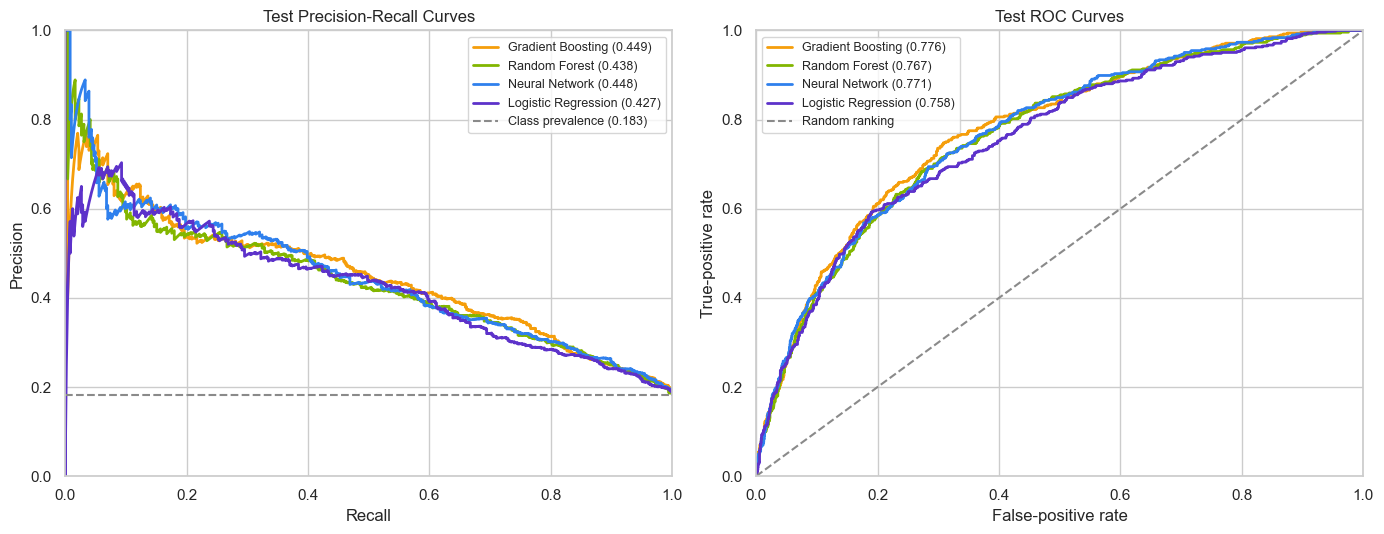

In [7]:
figure, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for model_name in MODEL_ORDER:
    probabilities = probability_by_model[model_name]

    precision, recall, _ = precision_recall_curve(
        y_test,
        probabilities,
    )
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test,
        probabilities,
    )

    model_row = ranking_results.loc[
        ranking_results["Model"] == model_name
    ].iloc[0]

    axes[0].plot(
        recall,
        precision,
        color=MODEL_COLORS[model_name],
        linewidth=2,
        label=f"{model_name} ({model_row['PR-AUC']:.3f})",
    )
    axes[1].plot(
        false_positive_rate,
        true_positive_rate,
        color=MODEL_COLORS[model_name],
        linewidth=2,
        label=f"{model_name} ({model_row['ROC-AUC']:.3f})",
    )

axes[0].axhline(
    y_test.mean(),
    color=GRAY,
    linestyle="--",
    label=f"Class prevalence ({y_test.mean():.3f})",
)
axes[0].set_title("Test Precision-Recall Curves")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=9)

axes[1].plot(
    [0, 1],
    [0, 1],
    color=GRAY,
    linestyle="--",
    label="Random ranking",
)
axes[1].set_title("Test ROC Curves")
axes[1].set_xlabel("False-positive rate")
axes[1].set_ylabel("True-positive rate")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

All four models clearly outperform their no-skill references on the untouched test set. Gradient boosting, the pre-committed primary model, has the highest PR-AUC (0.449), highest ROC-AUC (0.776), and lowest Brier score (0.125).

The neural network is extremely close at 0.448 PR-AUC, followed by random forest at 0.438 and logistic regression at 0.427. These gaps are small, so the later confidence intervals matter more than the third decimal place. The important result is that none of the learned models collapses when moved from cross-validation to participants that had no role in development.

## Checking Test-Set Calibration

A model can rank participants correctly while assigning probabilities that are too high or too low. The reliability diagram separates the test predictions into 10 equally sized probability groups and compares each group's mean prediction with its observed cavity rate.

Four related checks are used:

- **Calibration-in-the-large:** compares mean predicted probability with the observed 18.3% prevalence.
- **Brier score:** summarizes squared probability error, where lower is better.
- **Brier skill:** measures improvement over assigning the same prevalence-only probability to everyone. A value of 0 means no improvement over that constant model; positive values are better.
- **Calibration intercept and slope:** fit a logistic recalibration model to the predicted log-odds. An intercept of 0 and slope of 1 are ideal. A slope below 1 suggests probabilities are too extreme, while a slope above 1 suggests they are not extreme enough.

Matching the overall prevalence is useful but not sufficient by itself—a model predicting 0.183 for every participant would pass that one check while providing no useful ranking.

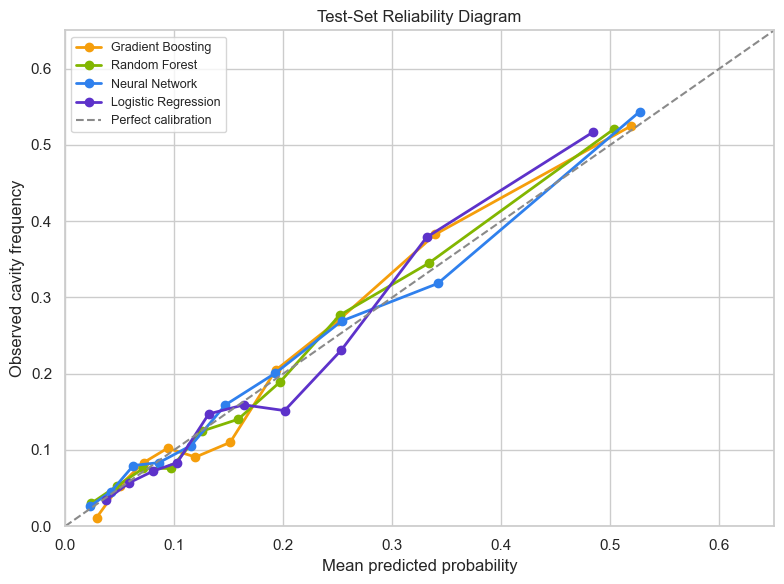

Prevalence-only Brier score: 0.150


,Model,Brier score,Brier skill,Mean predicted probability,Observed prevalence,Absolute prevalence gap,Calibration intercept,Calibration slope
0,Gradient Boosting,0.125,0.164,0.182,0.183,0.001,0.106,1.076
1,Random Forest,0.127,0.151,0.181,0.183,0.002,0.064,1.038
2,Neural Network,0.126,0.158,0.179,0.183,0.004,0.022,0.992
3,Logistic Regression,0.128,0.144,0.184,0.183,0.001,0.120,1.104


In [8]:
# The best constant-probability prediction under squared error is the
# observed prevalence. It provides a more informative Brier reference
# than describing 0.125 as "low" without any comparison.
prevalence_only_brier = y_test.mean() * (1 - y_test.mean())

calibration_rows = []
plt.figure(figsize=(8, 6))

for model_name in MODEL_ORDER:
    probabilities = probability_by_model[model_name]
    model_brier = brier_score_loss(y_test, probabilities)

    observed_fraction, mean_probability = calibration_curve(
        y_test,
        probabilities,
        n_bins=10,
        strategy="quantile",
    )

    # This regression is diagnostic only: its recalibrated predictions
    # are never substituted back into the evaluation. Clipping avoids
    # infinite log-odds if a future model outputs exactly 0 or 1.
    clipped_probabilities = np.clip(
        probabilities,
        1e-6,
        1 - 1e-6,
    )
    predicted_log_odds = logit(clipped_probabilities).reshape(-1, 1)

    # A very large C makes this effectively unpenalized while avoiding
    # the version-deprecated penalty=None argument in scikit-learn 1.8.
    recalibration_model = LogisticRegression(
        C=1e12,
        l1_ratio=0.0,
        solver="lbfgs",
        max_iter=1_000,
    ).fit(predicted_log_odds, y_test)

    plt.plot(
        mean_probability,
        observed_fraction,
        marker="o",
        linewidth=2,
        color=MODEL_COLORS[model_name],
        label=model_name,
    )

    calibration_rows.append(
        {
            "Model": model_name,
            "Brier score": model_brier,
            "Brier skill": 1 - model_brier / prevalence_only_brier,
            "Mean predicted probability": probabilities.mean(),
            "Observed prevalence": y_test.mean(),
            "Absolute prevalence gap": abs(
                probabilities.mean() - y_test.mean()
            ),
            "Calibration intercept": (
                recalibration_model.intercept_[0]
            ),
            "Calibration slope": (
                recalibration_model.coef_[0, 0]
            ),
        }
    )

plt.plot(
    [0, 1],
    [0, 1],
    color=GRAY,
    linestyle="--",
    label="Perfect calibration",
)
plt.title("Test-Set Reliability Diagram")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed cavity frequency")
plt.xlim(0, 0.65)
plt.ylim(0, 0.65)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

test_calibration = pd.DataFrame(calibration_rows)

# Add the richer calibration diagnostics to the main results table so
# the later CSV preserves them rather than only displaying them here.
model_test_results = model_test_results.merge(
    test_calibration.drop(columns="Brier score"),
    on="Model",
    how="left",
    validate="one_to_one",
)

print(
    "Prevalence-only Brier score: "
    f"{prevalence_only_brier:.3f}"
)
test_calibration.round(
    {
        "Brier score": 3,
        "Brier skill": 3,
        "Mean predicted probability": 3,
        "Observed prevalence": 3,
        "Absolute prevalence gap": 3,
        "Calibration intercept": 3,
        "Calibration slope": 3,
    }
)

Calibration is reasonable but not perfect. The test prevalence is 0.183, while mean predicted probability ranges from 0.179 to 0.184 across the four models. Gradient boosting averages 0.182, so it is close in the large, but that agreement alone would not establish good calibration.

The prevalence-only Brier score is 0.150. Gradient boosting lowers it to 0.125, corresponding to Brier skill of 0.164—a 16.4% reduction in squared probability error relative to giving everyone the same 18.3% probability. Its calibration intercept is 0.106 and slope is 1.076, reasonably close to the ideal values of 0 and 1. The other models have positive Brier skill of about 0.144–0.158 and slopes between 0.992 and 1.104.

The individual points do not fall perfectly on the diagonal. Because `strategy="quantile"` gives each bin roughly 264 participants, the deviations in the upper bins are not caused by smaller bin counts; they reflect ordinary sampling variation and possible local miscalibration. The probabilities remain useful for ranking and thresholding within this project, but they should not be treated as exact clinical risks or assumed to stay calibrated in another population.

## Applying the Frozen Recall-Floor Thresholds

Ranking metrics evaluate every possible cutoff, but a screening-style decision needs one operating point. Each model now uses the threshold selected from Notebook 4's out-of-fold training predictions.

The most important threshold metrics are:

- **Recall:** the share of actual cavity cases flagged by the model
- **Specificity:** the share of participants without cavities correctly left unflagged
- **Precision:** the share of flagged participants who actually have a cavity
- **Negative predictive value (NPV):** the share of unflagged participants who actually do not have a cavity
- **Share flagged:** the fraction of the entire cohort sent for possible follow-up

The test set measures whether the training-derived rule transferred. It does not get to choose a replacement threshold.

In [9]:
operating_columns = [
    "Model",
    "Threshold",
    "Recall",
    "Specificity",
    "Precision",
    "NPV",
    "F1",
    "Balanced accuracy",
    "Accuracy",
    "Share flagged",
]

operating_results = model_test_results[operating_columns].copy()

operating_results.round(
    {
        "Threshold": 3,
        "Recall": 3,
        "Specificity": 3,
        "Precision": 3,
        "NPV": 3,
        "F1": 3,
        "Balanced accuracy": 3,
        "Accuracy": 3,
        "Share flagged": 3,
    }
)

,Model,Threshold,Recall,Specificity,Precision,NPV,F1,Balanced accuracy,Accuracy,Share flagged
0,Gradient Boosting,0.130,0.818,0.554,0.292,0.932,0.430,0.686,0.603,0.514
1,Random Forest,0.130,0.837,0.535,0.288,0.936,0.428,0.686,0.591,0.533
2,Neural Network,0.115,0.845,0.516,0.281,0.937,0.422,0.681,0.577,0.550
3,Logistic Regression,0.125,0.839,0.494,0.271,0.932,0.409,0.666,0.557,0.567


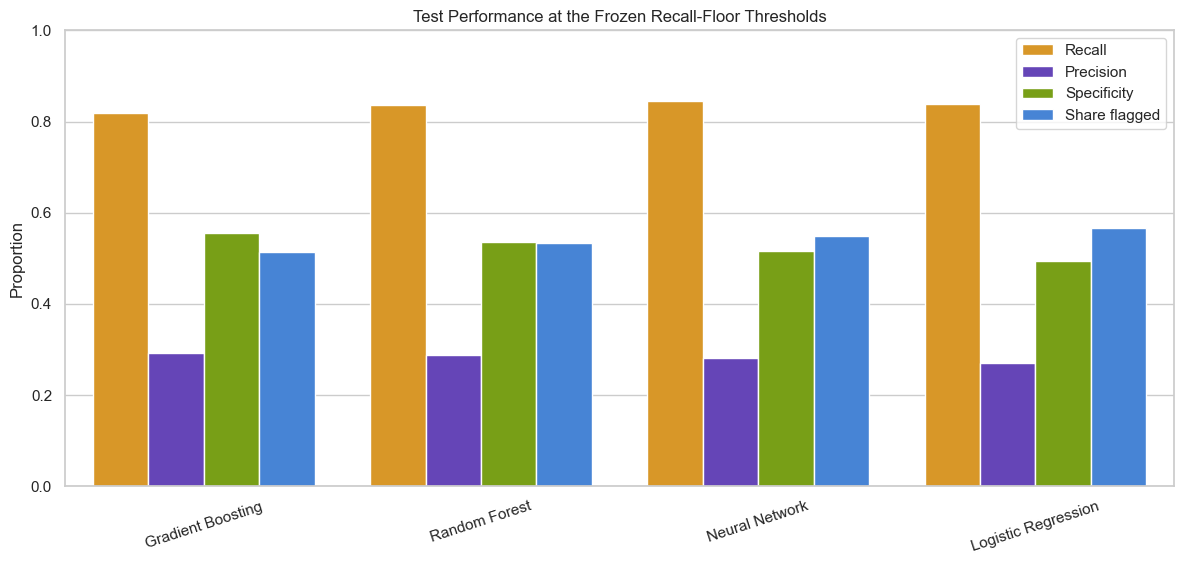

In [10]:
threshold_plot_data = operating_results.melt(
    id_vars="Model",
    value_vars=["Recall", "Precision", "Specificity", "Share flagged"],
    var_name="Metric",
    value_name="Score",
)

plt.figure(figsize=(12, 5.8))
axis = sns.barplot(
    data=threshold_plot_data,
    x="Model",
    y="Score",
    hue="Metric",
    palette=[ORANGE, PURPLE, GREEN, BLUE],
    order=MODEL_ORDER,
)

axis.set_title("Test Performance at the Frozen Recall-Floor Thresholds")
axis.set_xlabel("")
axis.set_ylabel("Proportion")
axis.set_ylim(0, 1)
axis.tick_params(axis="x", rotation=18)
axis.legend(title="")

plt.tight_layout()
plt.show()

All four frozen thresholds reach at least 0.818 recall on the test set. The neural network is highest at 0.845, logistic regression and random forest are near 0.84, and gradient boosting reaches 0.818.

The four models operate at closely matched recall, which makes their precision and flagged shares directly useful for comparison. Gradient boosting catches 81.8% of cases while flagging 51.4% of participants, fewer than every other model, and therefore has the highest precision at this operating point (0.292). That matched-recall efficiency is the main threshold-based argument in its favor. Its specificity (0.554), F1 (0.430), and balanced accuracy (0.686) are also the highest point estimates, but balanced accuracy is descriptive here rather than a new model-selection rule.

The low raw accuracies, about 0.56 to 0.60, are expected. Predicting “no cavity” for everyone would achieve 81.7% accuracy but detect zero cavities. The frozen thresholds deliberately sacrifice that misleading majority-class accuracy to catch more than 80% of the positive cases.

## Understanding the Primary Model's Errors

A confusion matrix converts the gradient-boosting percentages into participant counts. Rows show the actual dental examination outcome and columns show the model's flag at the frozen 0.130 threshold.

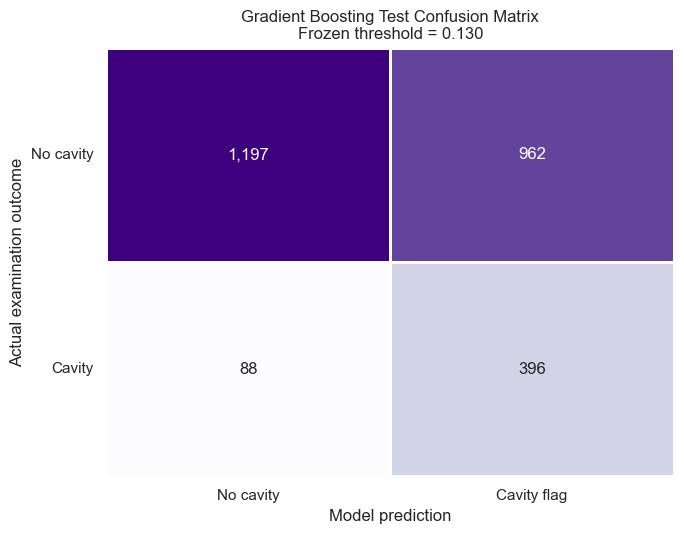

,Question,Result
0,How many cavity cases were caught?,396 of 484
1,How many cavity cases were missed?,88
2,How many participants without cavities were flagged?,962
3,How many participants without cavities were left unflagged?,"1,197"
4,What share of cavity cases were caught?,81.8%
5,What share of flags were true cavity cases?,29.2%
6,What share of unflagged participants had no cavity?,93.2%


In [11]:
primary_row = model_test_results.loc[
    model_test_results["Model"] == primary_model
].iloc[0]

primary_confusion_matrix = np.array(
    [
        [
            primary_row["True negatives"],
            primary_row["False positives"],
        ],
        [
            primary_row["False negatives"],
            primary_row["True positives"],
        ],
    ],
    dtype=int,
)

plt.figure(figsize=(7, 5.5))
axis = sns.heatmap(
    primary_confusion_matrix,
    annot=True,
    fmt=",d",
    cmap="Purples",
    cbar=False,
    linewidths=1,
    linecolor="white",
)
axis.set_title(
    "Gradient Boosting Test Confusion Matrix\n"
    f"Frozen threshold = {frozen_thresholds[primary_model]:.3f}"
)
axis.set_xlabel("Model prediction")
axis.set_ylabel("Actual examination outcome")
axis.set_xticklabels(["No cavity", "Cavity flag"])
axis.set_yticklabels(["No cavity", "Cavity"], rotation=0)
plt.tight_layout()
plt.show()

primary_story = pd.DataFrame(
    {
        "Question": [
            "How many cavity cases were caught?",
            "How many cavity cases were missed?",
            "How many participants without cavities were flagged?",
            "How many participants without cavities were left unflagged?",
            "What share of cavity cases were caught?",
            "What share of flags were true cavity cases?",
            "What share of unflagged participants had no cavity?",
        ],
        "Result": [
            f"{int(primary_row['True positives']):,} of {int(y_test.sum()):,}",
            f"{int(primary_row['False negatives']):,}",
            f"{int(primary_row['False positives']):,}",
            f"{int(primary_row['True negatives']):,}",
            f"{primary_row['Recall']:.1%}",
            f"{primary_row['Precision']:.1%}",
            f"{primary_row['NPV']:.1%}",
        ],
    }
)

primary_story

Gradient boosting catches 396 of the 484 cavity cases and misses 88. It also flags 962 participants who do not have a cavity, which is the price of operating at high recall.

A rough group of 100 participants makes the tradeoff easier to picture:

- about 18 would have an untreated cavity
- the model would catch about 15 and miss about 3
- about 51 people would be flagged altogether
- about 29% of those flags would represent a true cavity case

The model is therefore better suited to prioritizing who may need an examination than to diagnosing cavities by itself. An unflagged result is more reassuring than a flagged result is definitive: NPV is 93.2%, while precision is 29.2%.

## Why the Default 0.50 Threshold Is Not the Main Result

The models output probabilities, not automatic decisions. A 0.50 cutoff is conventional, but it would mean requiring the model to be more than 50% confident before flagging a participant which is far too strict when only 18.3% of the cohort has the outcome.

The table below changes only gradient boosting's cutoff. The fitted model and its probabilities remain identical.

In [12]:
primary_probability = probability_by_model[primary_model]

recall_floor_metrics = calculate_metrics(
    y_test,
    primary_probability,
    frozen_thresholds[primary_model],
)
default_metrics = calculate_metrics(
    y_test,
    primary_probability,
    0.50,
)

default_threshold_comparison = pd.DataFrame(
    [
        {
            "Threshold rule": "Frozen 80% recall-floor threshold",
            **recall_floor_metrics,
        },
        {
            "Threshold rule": "Conventional 0.50 threshold",
            **default_metrics,
        },
    ]
)[
    [
        "Threshold rule",
        "Threshold",
        "Recall",
        "Precision",
        "Specificity",
        "Accuracy",
        "Share flagged",
    ]
]

default_threshold_comparison.round(
    {
        "Threshold": 3,
        "Recall": 3,
        "Precision": 3,
        "Specificity": 3,
        "Accuracy": 3,
        "Share flagged": 3,
    }
)

,Threshold rule,Threshold,Recall,Precision,Specificity,Accuracy,Share flagged
0,Frozen 80% recall-floor threshold,0.13,0.818,0.292,0.554,0.603,0.514
1,Conventional 0.50 threshold,0.50,0.159,0.583,0.975,0.825,0.050


At 0.50, gradient boosting would flag only 5.0% of participants and recall would collapse from 81.8% to 15.9%. Precision would improve from 29.2% to 58.3% and accuracy would rise to 82.5%, but the model would miss 407 of the 484 cavity cases.

Neither threshold makes the underlying model better. They represent different operating goals. Notebook 4 deliberately chose the lower cutoff because this project prioritizes finding cases over preserving majority-class accuracy.

## Decision-Curve Analysis

Recall and precision each describe one kind of error, but neither combines the two into a single statement about whether acting on the model is worthwhile. Decision-curve analysis does that through **net benefit**:

$$
\text{Net benefit}
=
\frac{TP}{N}
-
\frac{FP}{N}
\left(\frac{p_t}{1-p_t}\right)
$$

where, for whichever strategy is being scored:

- $TP$ — **true positives:** participants the strategy flags who do have a cavity.
- $FP$ — **false positives:** participants the strategy flags who do not have a cavity.
- $N$ — **total participants evaluated**, 2,643 here. Dividing by $N$ puts every strategy on a per-participant scale so they can be compared directly.
- $p_t$ — **threshold probability:** the assumed cost tradeoff, described below. It is the only quantity that varies along the horizontal axis.
- $p_t/(1-p_t)$ — **the weight**, also called the threshold odds: how much one false positive counts against one true positive.

Note that $TP$ and $FP$ depend on the strategy. Flagging everyone fixes them at 484 and 2,159 for every $p_t$, whereas the model's counts fall as $p_t$ rises and its cutoff tightens.

**Reading the formula.** The first term is the share of participants correctly flagged. The second term is the cost of the false alarms, converted into the same units by the weight $p_t/(1-p_t)$. Net benefit is therefore measured in *true-positive equivalents*. At the frozen threshold the model finds 15.0 cavities per 100 participants and gives back 5.4 per 100 in false-alarm cost, netting 9.5—the same score a hypothetical strategy would earn by finding 9.5 per 100 and raising no false alarms at all.

**What the horizontal axis is.** The threshold probability $p_t$ is not simply a cutoff; it is a statement about relative cost. It sets how many false alarms one missed cavity is worth. At the frozen threshold of 0.130 the weight is 0.149, so one false positive counts as 0.149 of a true positive—equivalently, one missed case is treated as roughly 6.7 unnecessary flags. Moving right along the axis re-asks the same question under a progressively harsher view of false alarms.

**The two reference strategies.** Neither uses a model or any predictor:

- **Flag none:** nobody is referred, so net benefit is always exactly zero.
- **Flag all:** everybody is referred, so all 484 cavities in the test set are caught and all 2,159 participants without cavities are flagged.

**Why the curves take the shapes they do.** Flag-all is a fixed strategy: its 484 true positives and 2,159 false positives never change, so a rising weight increases its cost with no offsetting gain and its line falls steeply. It reaches zero at $p_t$ equal to the prevalence, 0.183, beyond which referring everyone is worse than referring nobody. The model can instead answer a harsher weight by flagging fewer participants, discarding false positives faster than it gives up true positives:

| Threshold probability | Weight | Model TP / FP | Model cost | Flag-all cost |
| --- | --- | --- | --- | --- |
| 0.050 | 0.053 | 474 / 1,771 | 93 | 114 |
| 0.130 | 0.149 | 396 / 962 | 144 | 323 |
| 0.250 | 0.333 | 277 / 383 | 128 | 720 |

Across that range the model sheds 78% of its false positives while surrendering 42% of its true positives, so its cost stays nearly flat while flag-all's grows more than sixfold. That gap, rather than any advantage in cavities found, is what separates the two curves. At the extreme left the cutoff falls below the model's lowest predicted probability, the model flags everyone, and the two curves meet.

This plot is descriptive, not another threshold search. The vertical line marks the 0.130 cutoff chosen in Notebook 4, and no test-set point is used to replace it.

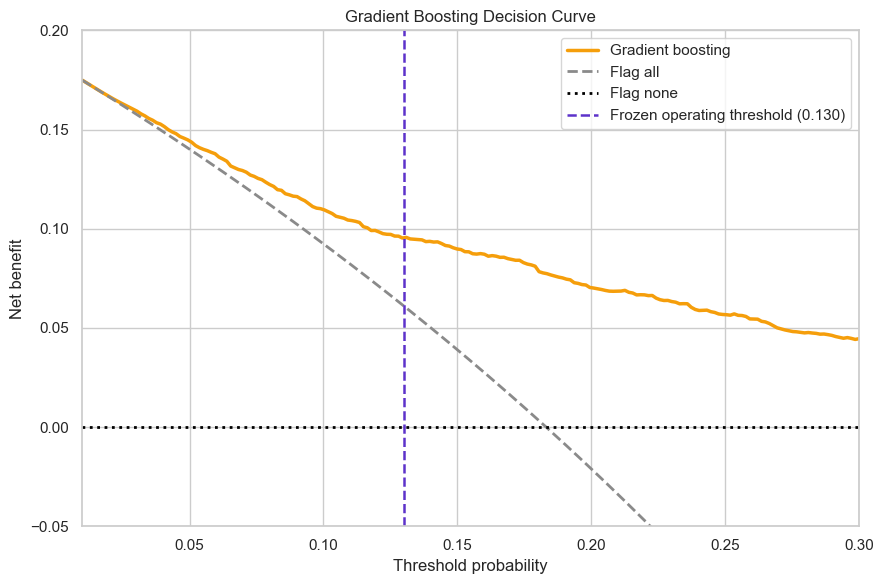

,Strategy at threshold 0.130,Net benefit,Net true-positive equivalents per 100
0,Gradient boosting,0.095,9.5
1,Flag all,0.061,6.1
2,Flag none,0.000,0.0


In [13]:
def calculate_net_benefit(labels, probabilities, threshold):
    """Return decision-curve net benefit at one threshold probability."""
    predictions = (probabilities >= threshold).astype(int)
    _, false_positive, _, true_positive = confusion_matrix(
        labels,
        predictions,
        labels=[0, 1],
    ).ravel()

    # Threshold odds translate a false-positive flag into the same
    # units as a true positive. Higher thresholds penalize false
    # positives more heavily.
    false_positive_weight = threshold / (1 - threshold)
    return (
        true_positive / len(labels)
        - false_positive / len(labels) * false_positive_weight
    )


decision_thresholds = np.linspace(0.01, 0.30, 200)
decision_curve_rows = []

for threshold in decision_thresholds:
    decision_curve_rows.append(
        {
            "Threshold probability": threshold,
            "Gradient boosting": calculate_net_benefit(
                y_test,
                primary_probability,
                threshold,
            ),
            "Flag all": (
                y_test.mean()
                - (1 - y_test.mean())
                * threshold
                / (1 - threshold)
            ),
            "Flag none": 0.0,
        }
    )

decision_curve_results = pd.DataFrame(decision_curve_rows)

plt.figure(figsize=(9, 6))
plt.plot(
    decision_curve_results["Threshold probability"],
    decision_curve_results["Gradient boosting"],
    color=ORANGE,
    linewidth=2.5,
    label="Gradient boosting",
)
plt.plot(
    decision_curve_results["Threshold probability"],
    decision_curve_results["Flag all"],
    color=GRAY,
    linestyle="--",
    linewidth=2,
    label="Flag all",
)
plt.plot(
    decision_curve_results["Threshold probability"],
    decision_curve_results["Flag none"],
    color="black",
    linestyle=":",
    linewidth=2,
    label="Flag none",
)
plt.axvline(
    frozen_thresholds[primary_model],
    color=PURPLE,
    linestyle="--",
    linewidth=1.8,
    label=(
        "Frozen operating threshold "
        f"({frozen_thresholds[primary_model]:.3f})"
    ),
)
plt.title("Gradient Boosting Decision Curve")
plt.xlabel("Threshold probability")
plt.ylabel("Net benefit")
plt.xlim(0.01, 0.30)
plt.ylim(-0.05, 0.20)
plt.legend()
plt.tight_layout()
plt.show()

operating_threshold = frozen_thresholds[primary_model]
primary_net_benefit = calculate_net_benefit(
    y_test,
    primary_probability,
    operating_threshold,
)
flag_all_net_benefit = (
    y_test.mean()
    - (1 - y_test.mean())
    * operating_threshold
    / (1 - operating_threshold)
)

decision_summary = pd.DataFrame(
    {
        "Strategy at threshold 0.130": [
            "Gradient boosting",
            "Flag all",
            "Flag none",
        ],
        "Net benefit": [
            primary_net_benefit,
            flag_all_net_benefit,
            0.0,
        ],
        "Net true-positive equivalents per 100": [
            primary_net_benefit * 100,
            flag_all_net_benefit * 100,
            0.0,
        ],
    }
)

decision_summary.round(
    {
        "Net benefit": 3,
        "Net true-positive equivalents per 100": 1,
    }
)

At the frozen 0.130 threshold, gradient boosting has net benefit of 0.095, compared with 0.061 for flagging everyone and 0 for flagging no one. On this threshold's weighting scale, the model adds about **3.4 net true-positive equivalents per 100 participants** compared with flagging everyone.

That supports the idea that the model's reduction in false-positive flags is useful under the project's stated tradeoff. It does not establish clinical utility by itself: the threshold probability and its implied cost ratio were chosen for this project, not elicited from patients, dentists, or a validated care pathway.

## Adding Bootstrap Confidence Intervals

Every reported score comes from one finite test sample. A second random sample from the same underlying cohort would produce slightly different numbers even if the model behaved the same way.

The bootstrap estimates that sampling uncertainty:

1. Draw 2,643 test rows with replacement.
2. Recalculate every metric using the already-fixed probabilities and thresholds.
3. Repeat the process 2,000 times.
4. Use the 2.5th and 97.5th percentiles as a 95% confidence interval.

The same resampled row indices are used for all four models in each repetition, keeping their comparisons paired. The models are never retrained inside the bootstrap.

These are ordinary participant-level intervals for this analytic cohort. They do not incorporate NHANES survey weights or PSU clustering and should not be interpreted as uncertainty around a nationally representative estimate.

In [14]:
bootstrap_metric_names = [
    "PR-AUC",
    "ROC-AUC",
    "Brier score",
    "Recall",
    "Specificity",
    "Precision",
    "NPV",
    "F1",
    "Balanced accuracy",
    "Accuracy",
    "Share flagged",
]

random_generator = np.random.default_rng(RANDOM_STATE)
labels_array = y_test.to_numpy()
bootstrap_rows = []

for bootstrap_number in range(1, N_BOOTSTRAPS + 1):
    sampled_indices = random_generator.integers(
        0,
        len(labels_array),
        len(labels_array),
    )
    sampled_labels = labels_array[sampled_indices]

    # Both classes must be present for PR-AUC and ROC-AUC. With 484
    # cavity cases this is overwhelmingly likely, but the guard keeps
    # the code correct for smaller future test sets.
    if np.unique(sampled_labels).size < 2:
        continue

    for model_name in MODEL_ORDER:
        sampled_probabilities = probability_by_model[model_name][
            sampled_indices
        ]
        sampled_metrics = calculate_metrics(
            sampled_labels,
            sampled_probabilities,
            frozen_thresholds[model_name],
        )

        bootstrap_rows.append(
            {
                "Bootstrap iteration": bootstrap_number,
                "Model": model_name,
                **{
                    metric_name: sampled_metrics[metric_name]
                    for metric_name in bootstrap_metric_names
                },
            }
        )

bootstrap_distributions = pd.DataFrame(bootstrap_rows)
completed_bootstraps = bootstrap_distributions[
    "Bootstrap iteration"
].nunique()

assert completed_bootstraps == N_BOOTSTRAPS
assert len(bootstrap_distributions) == N_BOOTSTRAPS * len(MODEL_ORDER)

interval_rows = []
point_estimate_lookup = model_test_results.set_index("Model")

for model_name in MODEL_ORDER:
    model_bootstraps = bootstrap_distributions.loc[
        bootstrap_distributions["Model"] == model_name
    ]

    for metric_name in bootstrap_metric_names:
        lower_bound, upper_bound = model_bootstraps[
            metric_name
        ].quantile([0.025, 0.975])

        interval_rows.append(
            {
                "Model": model_name,
                "Metric": metric_name,
                "Estimate": point_estimate_lookup.loc[
                    model_name,
                    metric_name,
                ],
                "Lower 95%": lower_bound,
                "Upper 95%": upper_bound,
            }
        )

bootstrap_intervals = pd.DataFrame(interval_rows)
print(
    f"Completed {completed_bootstraps:,} paired participant-level "
    "bootstrap repetitions."
)

KeyboardInterrupt: 

In [ ]:
primary_metric_order = [
    "PR-AUC",
    "ROC-AUC",
    "Brier score",
    "Recall",
    "Specificity",
    "Precision",
    "NPV",
    "F1",
    "Balanced accuracy",
    "Accuracy",
    "Share flagged",
]

primary_intervals = bootstrap_intervals.loc[
    bootstrap_intervals["Model"] == primary_model
].copy()
primary_intervals["Metric"] = pd.Categorical(
    primary_intervals["Metric"],
    categories=primary_metric_order,
    ordered=True,
)
primary_intervals = primary_intervals.sort_values("Metric")

primary_intervals.round(
    {
        "Estimate": 3,
        "Lower 95%": 3,
        "Upper 95%": 3,
    }
).reset_index(drop=True)

,Model,Metric,Estimate,Lower 95%,Upper 95%
0,Gradient Boosting,PR-AUC,0.449,0.406,0.496
1,Gradient Boosting,ROC-AUC,0.776,0.753,0.798
2,Gradient Boosting,Brier score,0.125,0.117,0.133
3,Gradient Boosting,Recall,0.818,0.782,0.852
4,Gradient Boosting,Specificity,0.554,0.534,0.575
5,Gradient Boosting,Precision,0.292,0.267,0.315
6,Gradient Boosting,NPV,0.932,0.917,0.945
7,Gradient Boosting,F1,0.430,0.400,0.457
8,Gradient Boosting,Balanced accuracy,0.686,0.666,0.705
9,Gradient Boosting,Accuracy,0.603,0.584,0.621


In [ ]:
compact_interval_metrics = [
    "PR-AUC",
    "ROC-AUC",
    "Recall",
    "Precision",
    "Specificity",
    "F1",
]

compact_intervals = bootstrap_intervals.loc[
    bootstrap_intervals["Metric"].isin(compact_interval_metrics)
].copy()
compact_intervals["Estimate (95% CI)"] = compact_intervals.apply(
    lambda row: (
        f"{row['Estimate']:.3f} "
        f"[{row['Lower 95%']:.3f}, {row['Upper 95%']:.3f}]"
    ),
    axis=1,
)
compact_intervals["Metric"] = pd.Categorical(
    compact_intervals["Metric"],
    categories=compact_interval_metrics,
    ordered=True,
)

all_model_interval_table = (
    compact_intervals.pivot(
        index="Metric",
        columns="Model",
        values="Estimate (95% CI)",
    )
    .reindex(compact_interval_metrics)
    .reindex(columns=MODEL_ORDER)
)

all_model_interval_table

Model,Gradient Boosting,Random Forest,Neural Network,Logistic Regression
Metric,,,,
PR-AUC,"0.449 [0.406, 0.496]","0.438 [0.394, 0.483]","0.448 [0.404, 0.493]","0.427 [0.385, 0.475]"
ROC-AUC,"0.776 [0.753, 0.798]","0.767 [0.743, 0.789]","0.771 [0.747, 0.793]","0.758 [0.733, 0.781]"
Recall,"0.818 [0.782, 0.852]","0.837 [0.803, 0.870]","0.845 [0.812, 0.876]","0.839 [0.805, 0.873]"
Precision,"0.292 [0.267, 0.315]","0.288 [0.265, 0.310]","0.281 [0.259, 0.304]","0.271 [0.249, 0.292]"
Specificity,"0.554 [0.534, 0.575]","0.535 [0.515, 0.556]","0.516 [0.495, 0.537]","0.494 [0.473, 0.514]"
F1,"0.430 [0.400, 0.457]","0.428 [0.400, 0.454]","0.422 [0.395, 0.449]","0.409 [0.382, 0.435]"


In [ ]:
# Marginal confidence intervals answer how uncertain each model's score
# is. They do not directly answer how uncertain the difference between
# two models is. Because every bootstrap iteration used the same rows
# for all four models, the paired differences below answer that second
# question without discarding the shared-participant design.
comparison_metrics = ["PR-AUC", "ROC-AUC", "Brier score"]
paired_rows = []

for metric_name in comparison_metrics:
    wide_bootstraps = bootstrap_distributions.pivot(
        index="Bootstrap iteration",
        columns="Model",
        values=metric_name,
    )
    assert len(wide_bootstraps) == N_BOOTSTRAPS

    for other_model in MODEL_ORDER[1:]:
        paired_difference = (
            wide_bootstraps[primary_model]
            - wide_bootstraps[other_model]
        )
        lower_bound, upper_bound = paired_difference.quantile(
            [0.025, 0.975]
        )
        observed_difference = (
            point_estimate_lookup.loc[primary_model, metric_name]
            - point_estimate_lookup.loc[other_model, metric_name]
        )

        # Higher is better for both AUC metrics, but lower is better
        # for Brier score. The direction check therefore changes for
        # the probability-error metric.
        excludes_zero = bool(lower_bound > 0 or upper_bound < 0)
        if not excludes_zero:
            interpretation = "No clear paired difference"
        elif metric_name == "Brier score" and upper_bound < 0:
            interpretation = "Gradient boosting lower (better)"
        elif metric_name != "Brier score" and lower_bound > 0:
            interpretation = "Gradient boosting higher (better)"
        else:
            interpretation = f"{other_model} favored"

        paired_rows.append(
            {
                "Metric": metric_name,
                "Comparison": (
                    f"{primary_model} minus {other_model}"
                ),
                "Observed difference": observed_difference,
                "Lower 95%": lower_bound,
                "Upper 95%": upper_bound,
                "Excludes zero": excludes_zero,
                "Interpretation": interpretation,
            }
        )

paired_differences = pd.DataFrame(paired_rows)
paired_differences.round(
    {
        "Observed difference": 3,
        "Lower 95%": 3,
        "Upper 95%": 3,
    }
)

,Metric,Comparison,Observed difference,Lower 95%,Upper 95%,Excludes zero,Interpretation
0,PR-AUC,Gradient Boosting minus Random Forest,0.012,-0.008,0.032,False,No clear paired difference
1,PR-AUC,Gradient Boosting minus Neural Network,0.001,-0.018,0.021,False,No clear paired difference
2,PR-AUC,Gradient Boosting minus Logistic Regression,0.022,0.000,0.041,True,Gradient boosting higher (better)
3,ROC-AUC,Gradient Boosting minus Random Forest,0.010,0.000,0.019,True,Gradient boosting higher (better)
4,ROC-AUC,Gradient Boosting minus Neural Network,0.005,-0.004,0.014,False,No clear paired difference
5,ROC-AUC,Gradient Boosting minus Logistic Regression,0.019,0.009,0.028,True,Gradient boosting higher (better)
6,Brier score,Gradient Boosting minus Random Forest,-0.002,-0.004,-0.000,True,Gradient boosting lower (better)
7,Brier score,Gradient Boosting minus Neural Network,-0.001,-0.002,0.001,False,No clear paired difference
8,Brier score,Gradient Boosting minus Logistic Regression,-0.003,-0.005,-0.001,True,Gradient boosting lower (better)


Gradient boosting's test recall is 0.818 with a 95% bootstrap interval of approximately 0.782–0.852. The point estimate reaches the planned 80% target, but the interval crosses 0.80. That is direct evidence that the threshold targets high recall rather than guaranteeing it in every new sample.

Its PR-AUC is 0.449 (approximately 0.406–0.496), ROC-AUC is 0.776 (0.753–0.798), and precision is 0.292 (0.267–0.315). Those marginal intervals describe uncertainty around each individual score. The paired differences provide the valid model-to-model comparison:

- Against logistic regression, gradient boosting's advantage excludes zero for PR-AUC, ROC-AUC, and Brier score.
- Against random forest, the paired interval favors gradient boosting for ROC-AUC and Brier score, but the PR-AUC difference remains unclear.
- Against the neural network, none of the three paired intervals excludes zero.

These are descriptive 95% bootstrap intervals rather than multiplicity-adjusted hypothesis tests. The strongest supported conclusion is that gradient boosting improves on logistic regression, has some advantages over random forest, and is statistically difficult to distinguish from the neural network on this test set.

Gradient boosting remains the correct headline model because it was chosen before testing, not because Notebook 5 searched for the most favorable row. It is reassuring that the pre-committed model also has the best point estimates for PR-AUC, ROC-AUC, Brier score, precision, and specificity.

## Comparing Development and Test Performance

The final question is whether Notebook 4's training-only estimates were misleadingly optimistic. The comparison below places gradient boosting's cross-validated development estimates beside its untouched test results.

PR-AUC and ROC-AUC come from five-fold cross-validation, calibration comes from out-of-fold predictions, and the threshold metrics come from the frozen 0.130 training operating point. The test column uses the same fitted pipeline and threshold evaluated once on `test_data.csv`.

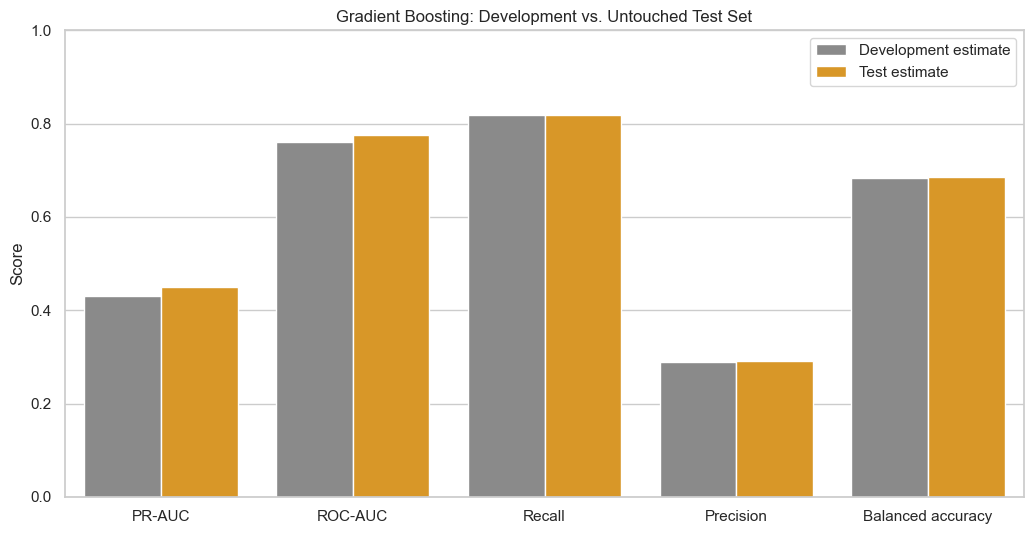

,Metric,Development estimate,Test estimate,Test minus development
0,PR-AUC,0.430,0.449,0.019
1,ROC-AUC,0.762,0.776,0.015
2,Brier score,0.128,0.125,-0.003
3,Recall,0.819,0.818,-0.001
4,Precision,0.290,0.292,0.002
5,Balanced accuracy,0.684,0.686,0.002
6,Share flagged,0.517,0.514,-0.004


In [ ]:
development_results = pd.read_csv(DEVELOPMENT_RESULTS_PATH).set_index("Model")
development_calibration = pd.read_csv(
    DEVELOPMENT_CALIBRATION_PATH
).set_index("Model")
development_thresholds = pd.read_csv(DEVELOPMENT_THRESHOLDS_PATH)
development_primary_threshold = development_thresholds.loc[
    (development_thresholds["Model"] == primary_model)
    & (
        development_thresholds["Threshold type"]
        == "Recall-floor (primary)"
    )
].iloc[0]

primary_test_lookup = model_test_results.set_index("Model").loc[
    primary_model
]

development_test_comparison = pd.DataFrame(
    {
        "Metric": [
            "PR-AUC",
            "ROC-AUC",
            "Brier score",
            "Recall",
            "Precision",
            "Balanced accuracy",
            "Share flagged",
        ],
        "Development estimate": [
            development_results.loc[
                primary_model,
                "average_precision_mean",
            ],
            development_results.loc[
                primary_model,
                "roc_auc_mean",
            ],
            development_calibration.loc[
                primary_model,
                "Brier score",
            ],
            development_primary_threshold["Recall"],
            development_primary_threshold["Precision"],
            development_primary_threshold["Balanced accuracy"],
            development_primary_threshold["Share flagged"],
        ],
        "Test estimate": [
            primary_test_lookup["PR-AUC"],
            primary_test_lookup["ROC-AUC"],
            primary_test_lookup["Brier score"],
            primary_test_lookup["Recall"],
            primary_test_lookup["Precision"],
            primary_test_lookup["Balanced accuracy"],
            primary_test_lookup["Share flagged"],
        ],
    }
)
development_test_comparison["Test minus development"] = (
    development_test_comparison["Test estimate"]
    - development_test_comparison["Development estimate"]
)

plot_metrics = [
    "PR-AUC",
    "ROC-AUC",
    "Recall",
    "Precision",
    "Balanced accuracy",
]
comparison_plot_data = development_test_comparison.loc[
    development_test_comparison["Metric"].isin(plot_metrics)
].melt(
    id_vars="Metric",
    value_vars=["Development estimate", "Test estimate"],
    var_name="Dataset",
    value_name="Score",
)

plt.figure(figsize=(10.5, 5.5))
axis = sns.barplot(
    data=comparison_plot_data,
    x="Metric",
    y="Score",
    hue="Dataset",
    palette=[GRAY, ORANGE],
    order=plot_metrics,
)
axis.set_title("Gradient Boosting: Development vs. Untouched Test Set")
axis.set_xlabel("")
axis.set_ylabel("Score")
axis.set_ylim(0, 1)
axis.legend(title="")
plt.tight_layout()
plt.show()

development_test_comparison.round(
    {
        "Development estimate": 3,
        "Test estimate": 3,
        "Test minus development": 3,
    }
)

Gradient boosting transfers cleanly:

- PR-AUC increases from 0.430 in development to 0.449 on the test set.
- ROC-AUC increases from 0.762 to 0.776.
- Brier score improves slightly from 0.128 to 0.125, where lower is better.
- Recall is almost unchanged: 0.819 in the out-of-fold training predictions and 0.818 on the test set.
- Precision is also nearly identical: 0.290 in development and 0.292 on the test set.

There is a structural reason the final model can score slightly better than its cross-validation estimate. Each five-fold development model was trained on about four-fifths of the 10,572-person training set, roughly 8,458 participants, while the saved pipeline was refit on all 10,572 before reaching the test set. That gives the final model about 25% more training data than any individual fold model, which can modestly improve generalization.

The extra data does not guarantee a higher test score; ordinary test-sample variation also contributes, and the tuned cross-validation scores can be slightly optimistic. The correct interpretation is that the small improvements are plausible and, more importantly, there is no evidence of a large generalization failure. The close transfer of recall is especially reassuring because the 0.130 threshold was chosen entirely from training predictions.

## Saving the Final Evaluation Artifacts

Five compact outputs preserve the complete evaluation without creating a separate file for every figure:

1. one row of final metrics per model,
2. one long table of bootstrap intervals,
3. one table of paired bootstrap differences,
4. one participant-level prediction table, and
5. one JSON record describing the test file, model files, frozen thresholds, calibration reference, decision curve, and bootstrap procedure.

The prediction table makes later error analysis and subgroup analysis possible without calling the models again.

In [ ]:
TEST_RESULTS_PATH = TABLE_FOLDER / "model_test_results.csv"
TEST_INTERVALS_PATH = TABLE_FOLDER / "model_test_bootstrap_intervals.csv"
TEST_PAIRED_PATH = TABLE_FOLDER / "model_test_paired_differences.csv"
TEST_PREDICTIONS_PATH = TABLE_FOLDER / "model_test_predictions.csv"
EVALUATION_METADATA_PATH = MODEL_FOLDER / "test_evaluation_metadata.json"

model_test_results.to_csv(TEST_RESULTS_PATH, index=False)
bootstrap_intervals.to_csv(TEST_INTERVALS_PATH, index=False)
paired_differences.to_csv(TEST_PAIRED_PATH, index=False)
test_predictions.to_csv(TEST_PREDICTIONS_PATH, index=False)

model_hashes = {
    model_name: hashlib.sha256(
        (MODEL_FOLDER / model_filenames[model_name]).read_bytes()
    ).hexdigest()
    for model_name in MODEL_ORDER
}

evaluation_metadata = {
    "test_file": TEST_PATH.name,
    "test_file_sha256": hashlib.sha256(TEST_PATH.read_bytes()).hexdigest(),
    "test_rows": len(test_data),
    "test_cavity_cases": int(y_test.sum()),
    "test_cavity_prevalence": float(y_test.mean()),
    "source_training_metadata": METADATA_PATH.name,
    "source_training_file_sha256": saved_training_hash,
    "primary_model": primary_model,
    "target_recall": target_recall,
    "frozen_thresholds": {
        model_name: float(frozen_thresholds[model_name])
        for model_name in MODEL_ORDER
    },
    "model_sha256": model_hashes,
    "calibration": {
        "brier_reference": "constant observed test prevalence",
        "prevalence_only_brier": float(prevalence_only_brier),
        "recalibration_target_intercept": 0.0,
        "recalibration_target_slope": 1.0,
    },
    "decision_curve": {
        "threshold_min": float(decision_thresholds.min()),
        "threshold_max": float(decision_thresholds.max()),
        "frozen_primary_threshold": float(operating_threshold),
        "primary_net_benefit": float(primary_net_benefit),
        "flag_all_net_benefit": float(flag_all_net_benefit),
        "used_for_threshold_selection": False,
    },
    "bootstrap": {
        "method": "ordinary participant-level percentile bootstrap",
        "resamples": N_BOOTSTRAPS,
        "confidence_level": 0.95,
        "random_state": RANDOM_STATE,
        "models_retrained": False,
        "paired_indices_across_models": True,
        "paired_comparison_metrics": comparison_metrics,
        "survey_design_incorporated": False,
    },
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "scikit_learn_version": sklearn.__version__,
}
EVALUATION_METADATA_PATH.write_text(
    json.dumps(evaluation_metadata, indent=2)
)

# Reload the saved tables and check their dimensions before declaring
# the evaluation complete.
reloaded_results = pd.read_csv(TEST_RESULTS_PATH)
reloaded_intervals = pd.read_csv(TEST_INTERVALS_PATH)
reloaded_paired = pd.read_csv(TEST_PAIRED_PATH)
reloaded_predictions = pd.read_csv(TEST_PREDICTIONS_PATH)

assert len(reloaded_results) == len(MODEL_ORDER)
assert len(reloaded_intervals) == (
    len(MODEL_ORDER) * len(bootstrap_metric_names)
)
assert len(reloaded_paired) == (
    len(comparison_metrics) * (len(MODEL_ORDER) - 1)
)
assert len(reloaded_predictions) == len(test_data)
assert reloaded_predictions["SEQN"].is_unique
assert reloaded_predictions.isna().sum().sum() == 0

saved_evaluation_files = pd.DataFrame(
    {
        "Artifact": [
            "Final model metrics",
            "Bootstrap confidence intervals",
            "Paired model differences",
            "Participant-level test predictions",
            "Evaluation metadata",
        ],
        "Saved file": [
            TEST_RESULTS_PATH.name,
            TEST_INTERVALS_PATH.name,
            TEST_PAIRED_PATH.name,
            TEST_PREDICTIONS_PATH.name,
            EVALUATION_METADATA_PATH.name,
        ],
    }
)

print("Every saved evaluation artifact reloaded successfully.")
saved_evaluation_files

Every saved evaluation artifact reloaded successfully.


,Artifact,Saved file
0,Final model metrics,model_test_results.csv
1,Bootstrap confidence intervals,model_test_bootstrap_intervals.csv
2,Paired model differences,model_test_paired_differences.csv
3,Participant-level test predictions,model_test_predictions.csv
4,Evaluation metadata,test_evaluation_metadata.json


The saved CSV files contain numbers only but figures remain embedded in the notebook. `model_test_predictions.csv` will be especially useful in Notebook 7, where the same fixed predictions can be evaluated across demographic groups without training or selecting another model.

## Limitations

This is a strong internal holdout evaluation, but its scope remains limited:

1. **The test set comes from the same NHANES analytic cohort as the training data.** It measures generalization to held-out participants under the same data-collection setting, not transport to a different survey cycle, dental clinic, or healthcare system.
2. **NHANES survey weights and clustering are not incorporated.** The metrics describe individual-level prediction in this analytic sample and should not be converted into national performance claims.
3. **The bootstrap treats participants as independent.** Its intervals capture ordinary test-sample variation conditional on the fitted models, but not PSU clustering, uncertainty from rebuilding the entire model-development pipeline, or external distribution shift.
4. **The 80% recall floor is a project choice.** It illustrates one screening-style tradeoff and has not been validated as an appropriate clinical decision threshold. The decision curve's net benefit depends on that same unvalidated weighting of false negatives against false positives.
5. **Several predictors are self-reported or access-related.** Good prediction does not establish that any predictor causes cavities, and subgroup performance still needs to be checked.

These limitations do not invalidate the test results. They define what the results can and cannot support.

## Conclusion

The final evaluation supports the main conclusions from model development:

- Gradient boosting remains the primary model and achieves **0.449 PR-AUC**, **0.776 ROC-AUC**, and a **0.125 Brier score** on the untouched test set.
- Its Brier skill is **0.164**, meaning its squared probability error is 16.4% lower than assigning the same prevalence-only probability to everyone. Its calibration intercept (0.106) and slope (1.076) are reasonably close to their ideal values of 0 and 1.
- At its frozen 0.130 threshold, it catches **396 of 484 cavity cases**, giving **81.8% recall**, **29.2% precision**, **55.4% specificity**, and **93.2% NPV**.
- The 95% bootstrap interval for recall is approximately **78.2%–85.2%**. The point estimate reaches the intended 80% target, but the result is not a guarantee that every future sample will.
- Paired bootstrap differences favor gradient boosting over logistic regression on PR-AUC, ROC-AUC, and Brier score; over random forest on ROC-AUC and Brier score; and do not clearly distinguish it from the neural network.
- At the illustrative 0.130 decision threshold, gradient boosting provides about **3.4 additional net true-positive equivalents per 100 participants** compared with flagging everyone, although this is not evidence of clinically validated utility.
- Gradient boosting's test performance is as strong as, and in several metrics slightly stronger than, its cross-validated development performance. There is no evidence of a large generalization collapse.
- The default 0.50 threshold would produce higher accuracy but detect only 15.9% of cavity cases, confirming why accuracy and an arbitrary cutoff were not appropriate primary choices.

This notebook completes the one-time model evaluation. Notebook 6 can now explain which predictors drive the saved models, while Notebook 7 can reuse the fixed test predictions to check whether performance is consistent across demographic groups.